# Задание 1

Возьмите код из лекции про генеративную MLP и постарайтесь получить `loss` на валидации ниже $2.1$. Для этого разрешается
 - менять гиперпараметры (Гиперпараметрами называют такие параметры сети, по которым не происходит оптимизация. Например, значения внутренних размерностей.)
 - менять расписание learning rate (не используйте расписания в pytorch, имплементируйте свои!)
 - добавлять слои, но только те, которые вы написали сами на основе `torch.tensor`. Никакие встроенные слои не разрешены
 - менять способы вложения букв/буквосочетаний.
 - менять инициализацию параметров
 
Запрещается:
- использовать `optim` из `torch`
- использовать готовые слои из pytorch.


# Задание 2
Цель этого задания - наглядно продемонстрировать, как плохо работает процедура инициализации весов при работе с нейросетью, состоящей из нескольких слоев разного размера :-)


## Задание 2.1

Напишите функцию generate_disc_set(nb), которая возвращает пару тензоров типов соответственно torch.float32, torch.int64 и размерами `nb×2` и `nb`, соответствующих `X` и `Y` игрушечного набора данных, где вход равномерно распределен в интервале `[−1,1]×[−1,1]`, и `Y` равен $1$ внутри диска радиусом $\sqrt{2/\pi}$ и $0$ снаружи. Создайте обучающий и тестовый наборы из 1,000 образцов и нормализуйте их среднее и дисперсию к 0 и 1. Простая проверка на адекватность - убедиться, что два класса сбалансированы. Постройте график полученного датасета 

In [40]:
import numpy as np
import torch as tr
import math
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
import numpy as np
import random

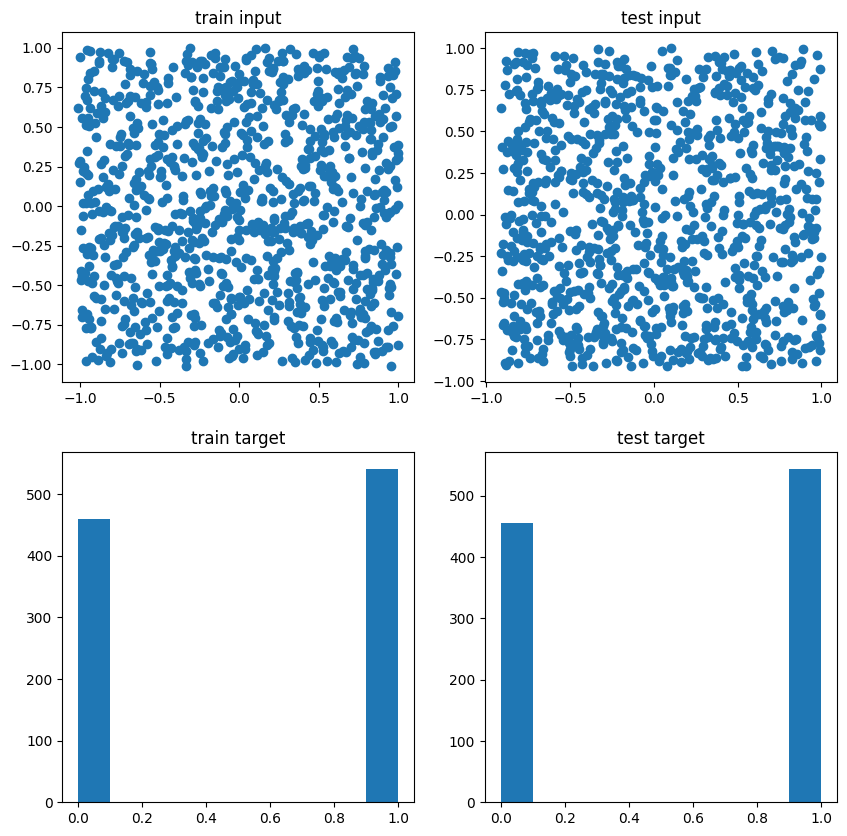

In [41]:
def generate_disc_data(nb):
    a = -1 
    b = 1
    X = tr.tensor([a + (b-a) * random.random() for _ in range(nb*2)]).view(-1, 2)
    X_mean = X.sum()/(nb*2)
    X_std =  (tr.sum(((X - X_mean))**2)/((nb*2) - 1))**(1/2)
    X = (X - X_mean) / X_std
    X = X / X.max()
    X = X.type(tr.float32)
    
    Y = tr.randint(-10000, 10000, (nb, 1))/1000
    for ix, y in enumerate(Y):
        if y >= ((2/tr.pi))**(1/2):
            Y[ix] = 0
        else:
            Y[ix] = 1
    Y = Y.type(tr.int64).flatten()
    return X, Y

train_input, train_target = generate_disc_data(1000)
test_input, test_target = generate_disc_data(1000)

# график тренировочной выборки
fig,ax = plt.subplots(2,2,figsize=(10,10))
ax[0][0].scatter(train_input[:,0],train_input[:,1])
ax[0][0].set_title('train input')

ax[0][1].scatter(test_input[:,0],test_input[:,1])
ax[0][1].set_title('test input')

ax[1][0].hist(train_target)
ax[1][0].set_title('train target')

ax[1][1].hist(test_target)
ax[1][1].set_title('test target')

plt.show()

In [42]:
train_target.unique(), test_target.unique()

(tensor([0, 1]), tensor([0, 1]))

## Задание 2.2
Напишите функции `train(model, input, target)` и `calc_nb_errors(model, input, target)`.

Первая функция должна обучать модель с использованием кросс-энтропии и 250 эпохами стандартного SGD (используйте optim.SGD) с `lr=0.1` и батчами размером 100.

Вторая функция также должна использовать батчи и возвращать целое число -- количество ошибок в классификации переданного датасета.

In [43]:
from torch import nn

simple_test_model = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 2),
    nn.Softmax(dim=1)
)
simple_test_model

Sequential(
  (0): Linear(in_features=2, out_features=200, bias=True)
  (1): ReLU()
  (2): Linear(in_features=200, out_features=2, bias=True)
  (3): Softmax(dim=1)
)

54.455999999999996


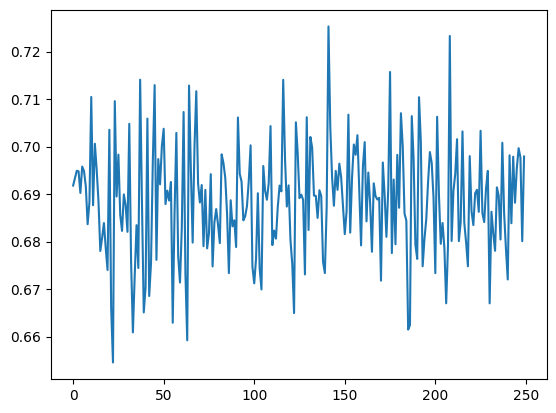

In [44]:
def train(model, input, target):
    
    max_epoch = 250
    lr = 0.1
    batch_size = 100
    
    opt = tr.optim.SGD(
        model.parameters(),
        lr = lr
    )
    loss_f = nn.CrossEntropyLoss()
    
    train_lossi = []
    train_acc = []
    
    model.train()
    for epoch in range(max_epoch):
        opt.zero_grad()
        
        ix = tr.randint(0, input.shape[0], (batch_size,))
        X = input[ix]
        
        Y_pred = model.forward(X)
        Y = target[ix]
        loss = loss_f(Y_pred, Y)
        train_lossi.append(loss.item())
        
        loss.backward()
        opt.step()
        
        
        to_acc = []
        for el in Y_pred:
            if el[0].item() > el[1].item():
                to_acc.append(0)
            else: 
                to_acc.append(1)
        to_acc = np.array(to_acc)
      
        train_acc.append(accuracy_score(to_acc,Y))
        
        # print(f"EPOCH: {epoch}")
        # print(f"TRAIN LOSS: {loss.item()}")
        
    model.eval()

    return train_lossi, 100 * sum(train_acc)/len(train_acc)

training = train(simple_test_model, train_input, train_target)
plt.plot(
    training[0]
);

print(training[1])

53.111111111111114


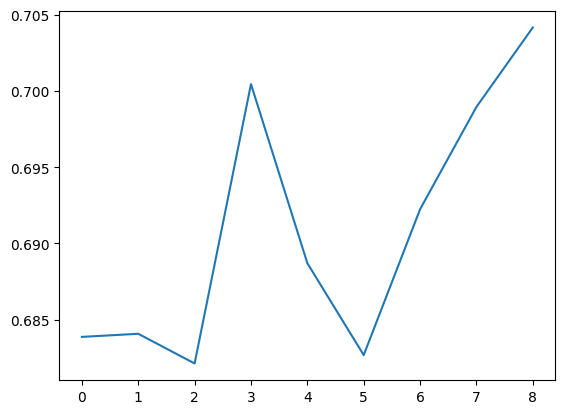

In [45]:
def calc_nb_errors(model, input, target):
  model.eval()

  loss_f = nn.CrossEntropyLoss()
  test_lossi = []
  test_acc = []
  batch_size = 100
  
  for ind in range(0, input.shape[0] - batch_size, batch_size):
      l = ind
      r = ind + batch_size
      ix = tr.arange(l,r).reshape((batch_size,))
      X = input[ix]
      
      Y_pred = model.forward(X)
      Y = target[ix]
      
      test_loss = loss_f(Y_pred, Y)
      
      test_lossi.append(test_loss.item())
      
      to_acc = []
      for el in Y_pred:
          if el[0].item() > el[1].item():
              to_acc.append(0)
          else: 
              to_acc.append(1)
      to_acc = np.array(to_acc)
      
      test_acc.append(accuracy_score(to_acc,Y))
      
      # print(f"EPOCH: {ind}")
      # print(f"TEST LOSSa: {test_loss}")
    
  return test_lossi, (100 * sum(test_acc)/len(test_acc))

te_l, acc = calc_nb_errors(simple_test_model, test_input, test_target)
print(acc)
plt.plot(te_l);

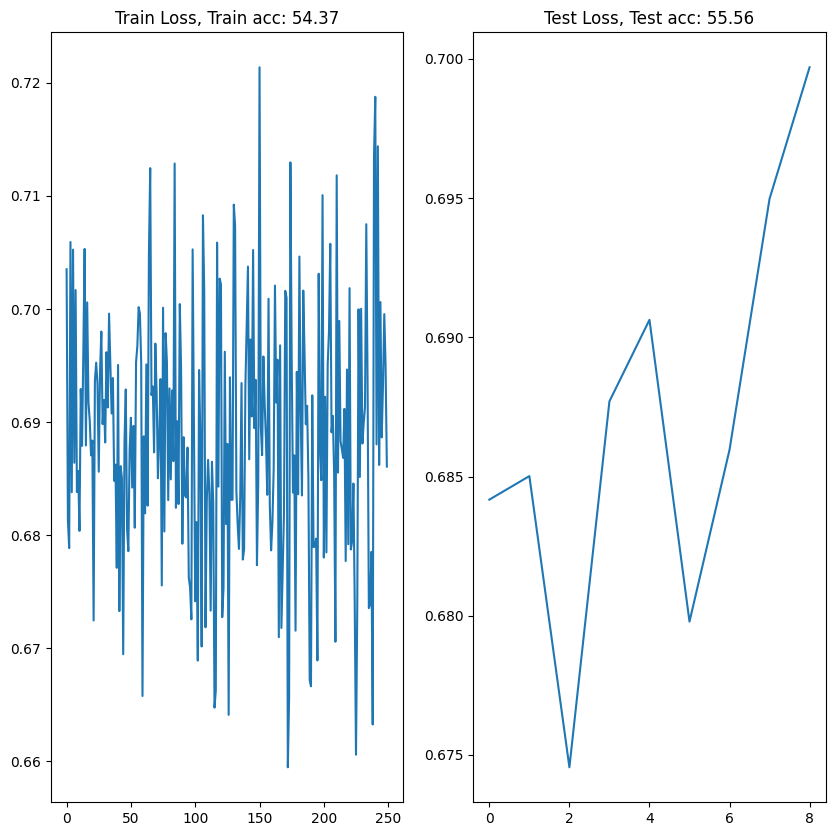

In [46]:
train_lossi, train_acc = train(simple_test_model, train_input, train_target)
test_lossi, test_acc = calc_nb_errors(simple_test_model, test_input, test_target)

def show_res(train_lossi, test_lossi, train_acc,test_acc):
    fig, ax = plt.subplots(1,2, figsize=(10,10))
    ax[0].plot(train_lossi)
    ax[0].set_title(f"Train Loss, Train acc: {train_acc:.2f}")
    ax[1].plot(test_lossi)
    ax[1].set_title(f"Test Loss, Test acc: {test_acc:.2f}")
    plt.show()
show_res(train_lossi, test_lossi,train_acc, test_acc)

## Задание 2.3
Напишите `make_shallow_model()`, которая возвращает многослойный перцептрон (MLP) с 2 входными юнитами, одним скрытым слоем размером 128 и 2 выходными юнитами, и `make_deep_model()`, которая возвращает MLP с 2 входными юнитами и скрытыми слоями с размерами соответственно 4, 8, 16, 32, 64, 128 и 2 выходными юнитами. Подсказка: вы можете использовать контейнер `nn.Sequential` для упрощения жизни. В качестве нелинейности используйте `nn.ReLU()`

In [47]:
shallow_model = nn.Sequential(
    nn.Linear(2,128),
    nn.ReLU(),
    nn.Linear(128,2),
    nn.Softmax(dim=1),
)

deep_model = nn.Sequential(
    nn.Linear(2,4),
    nn.ReLU(),
    
    nn.Linear(4,8),
    nn.ReLU(),
    
    nn.Linear(8,16),
    nn.ReLU(),
    
    nn.Linear(16,32),
    nn.ReLU(),
    
    nn.Linear(32,64),
    nn.ReLU(),
    
    nn.Linear(64,128),
    nn.ReLU(),
    
    nn.Linear(128,2),
    nn.Softmax(dim=1),
)

## Задание 2.4
Вычислите и выведете ошибки на обучающей и тестовой выборках для этих двух моделей, когда они инициализированы либо с использованием стандартной инициализации PyTorch, либо с нормальным распределением со стандартным отклонением $10^{-3}$, $10^{-2}$, $10^{-1}$, $1$ и $10$. Показатель ошибки с использованием неглубокой  сети для любой инициализации должен быть около $1.5$%. Для глубокой сети с использованием стандартной инициализации он должен быть около 3%, и около 50% в большинстве случаев с другими инициализациями.


######################################################################################################################################################
Result with MODEL : Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=2, bias=True)
  (3): Softmax(dim=1)
)
------------------------------------------------------------------------------------------------------------------------------------------------------


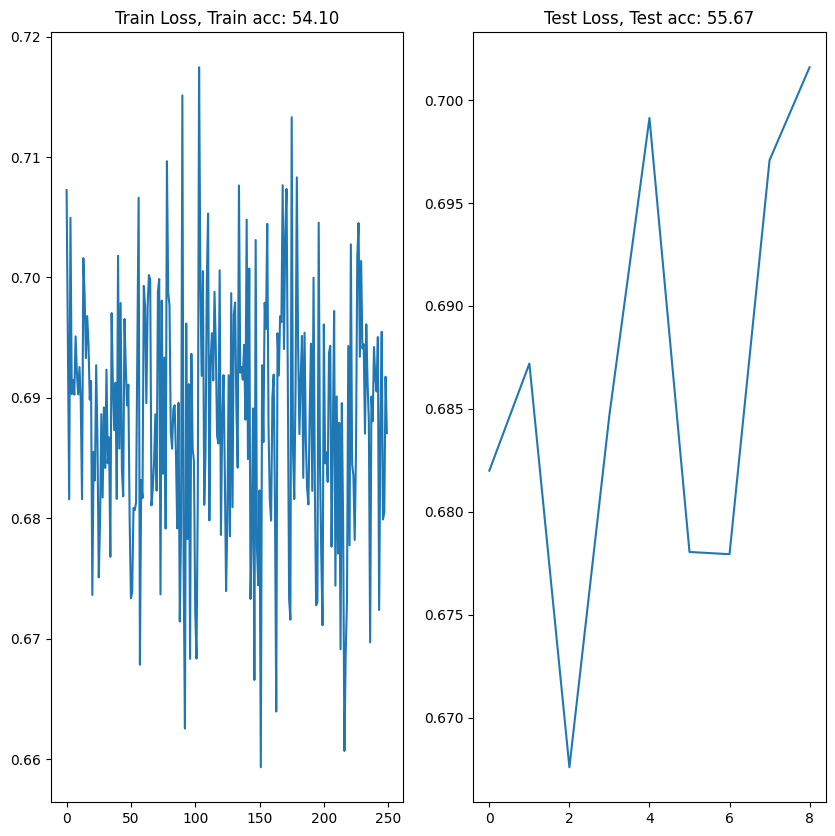

Result with STD : BASIC
------------------------------------------------------------------------------------------------------------------------------------------------------


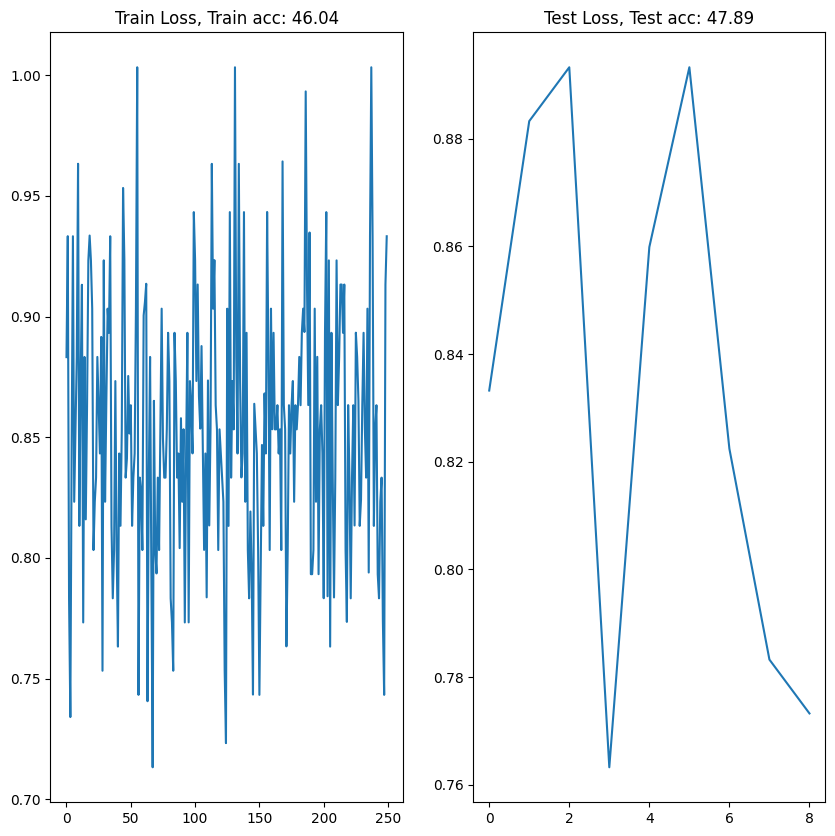

Result with STD : 10
------------------------------------------------------------------------------------------------------------------------------------------------------


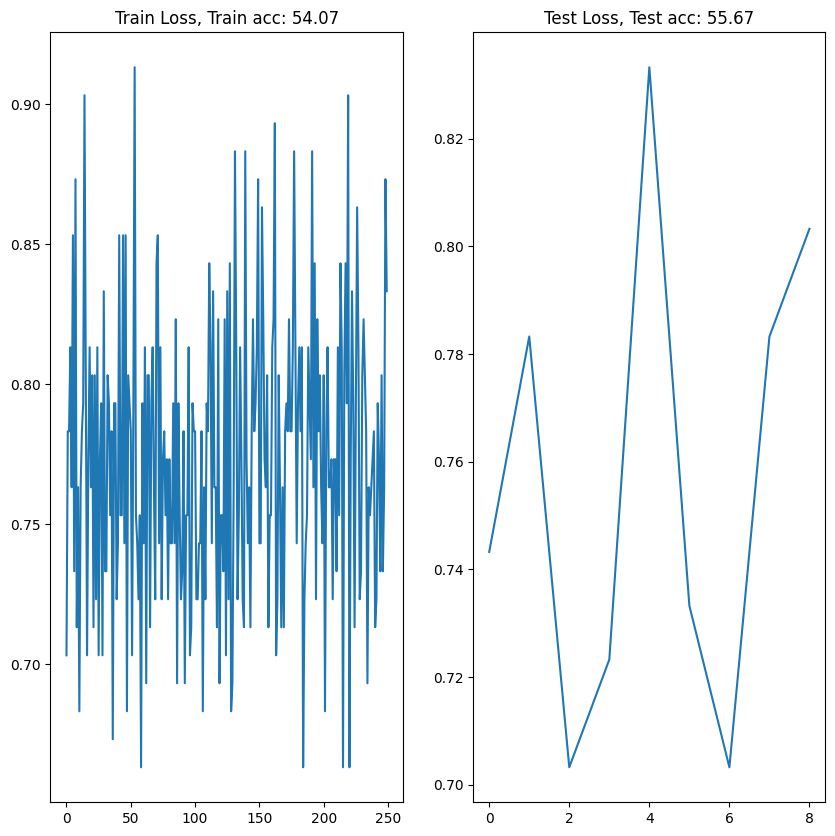

Result with STD : 1
------------------------------------------------------------------------------------------------------------------------------------------------------


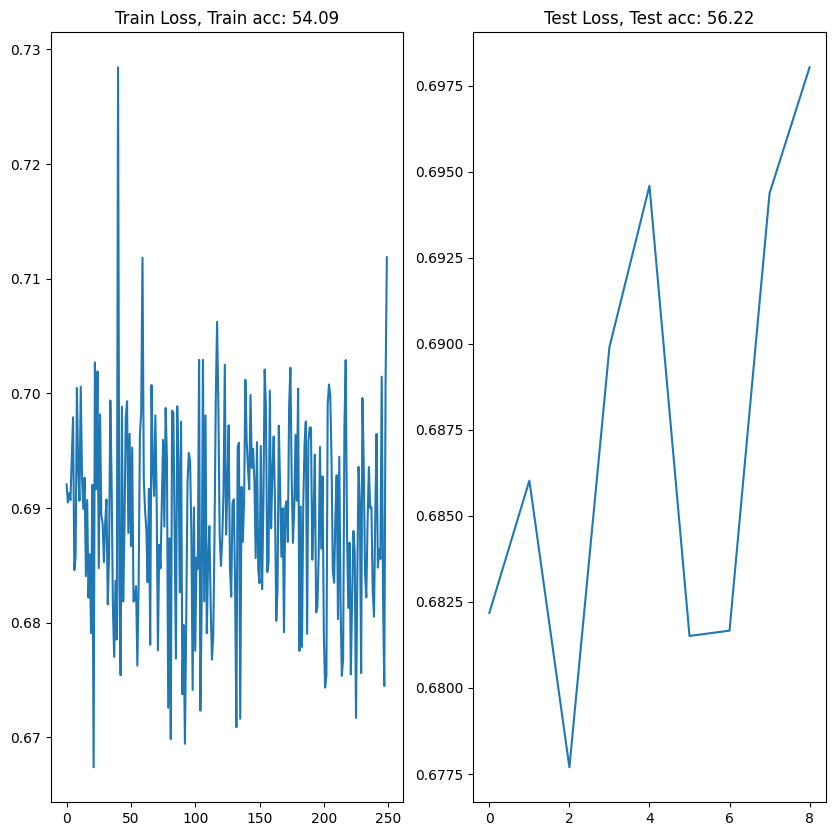

Result with STD : 0.1
------------------------------------------------------------------------------------------------------------------------------------------------------


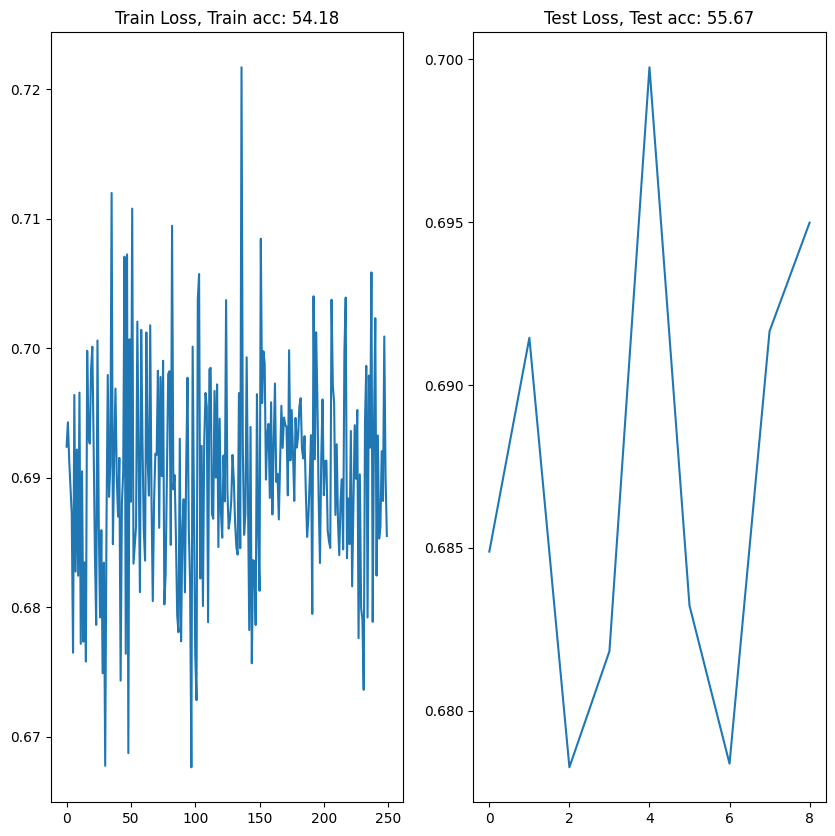

Result with STD : 0.01
------------------------------------------------------------------------------------------------------------------------------------------------------


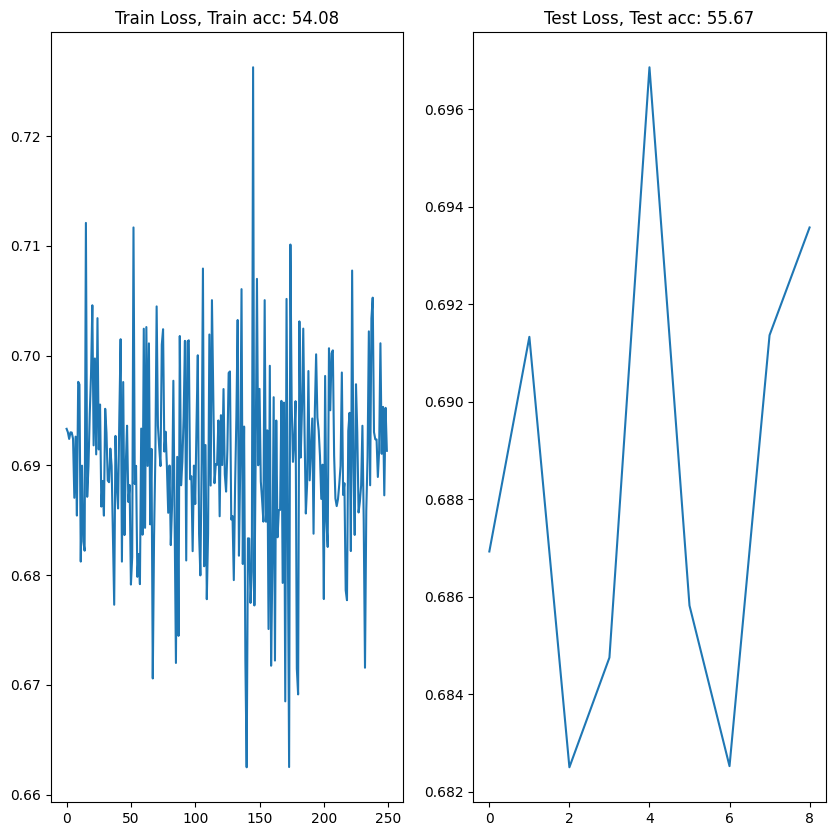

Result with STD : 0.001
######################################################################################################################################################
Result with MODEL : Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=64, bias=True)
  (9): ReLU()
  (10): Linear(in_features=64, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=2, bias=True)
  (13): Softmax(dim=1)
)
------------------------------------------------------------------------------------------------------------------------------------------------------


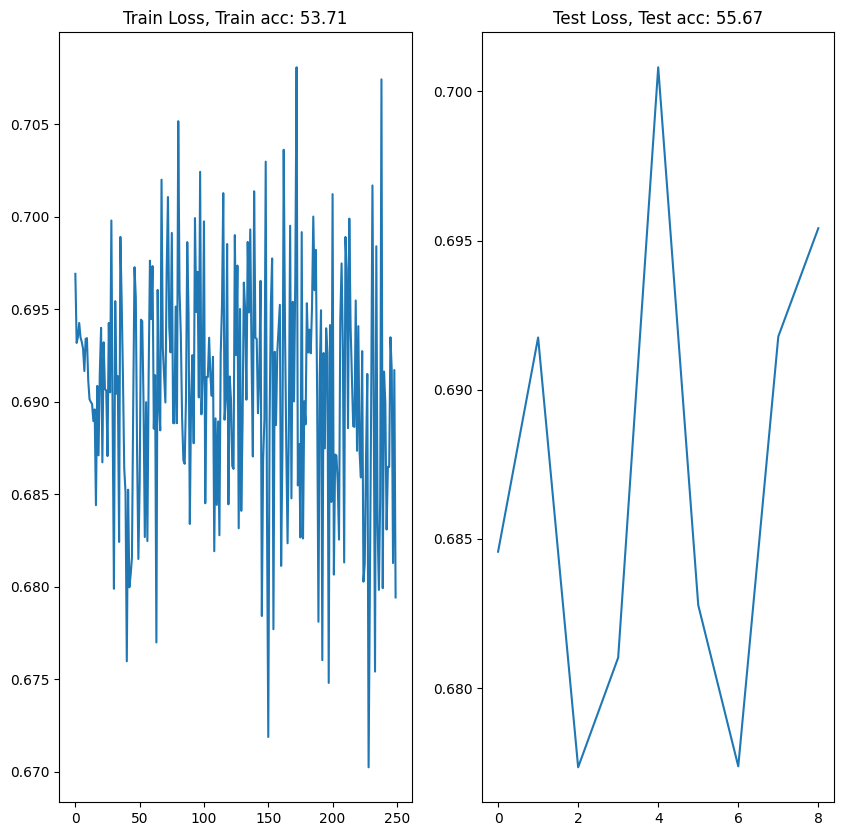

Result with STD : BASIC
------------------------------------------------------------------------------------------------------------------------------------------------------


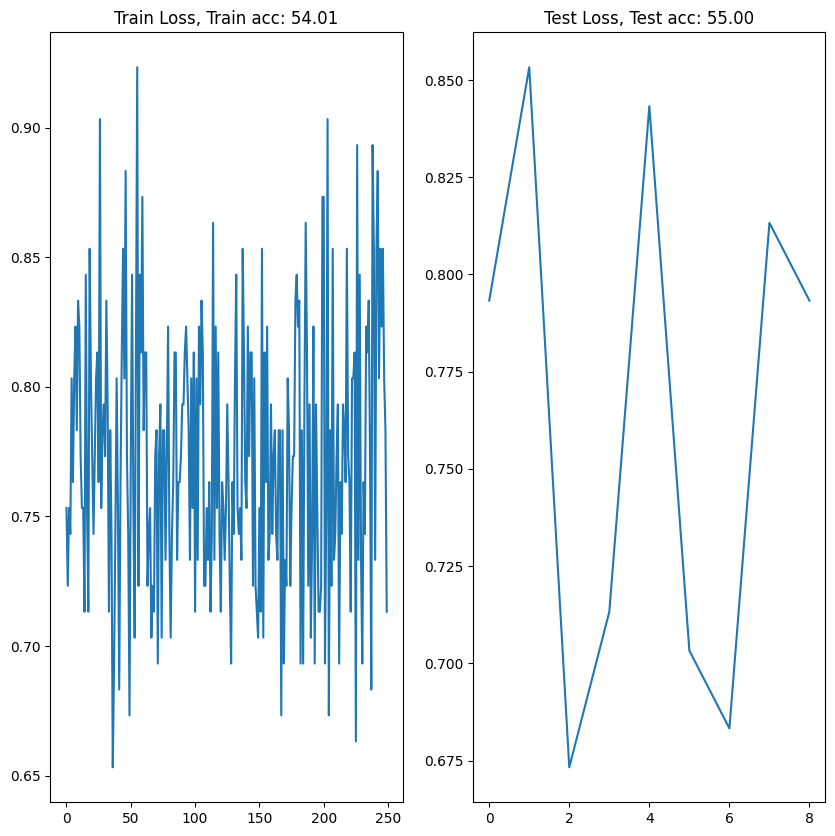

Result with STD : 10
------------------------------------------------------------------------------------------------------------------------------------------------------


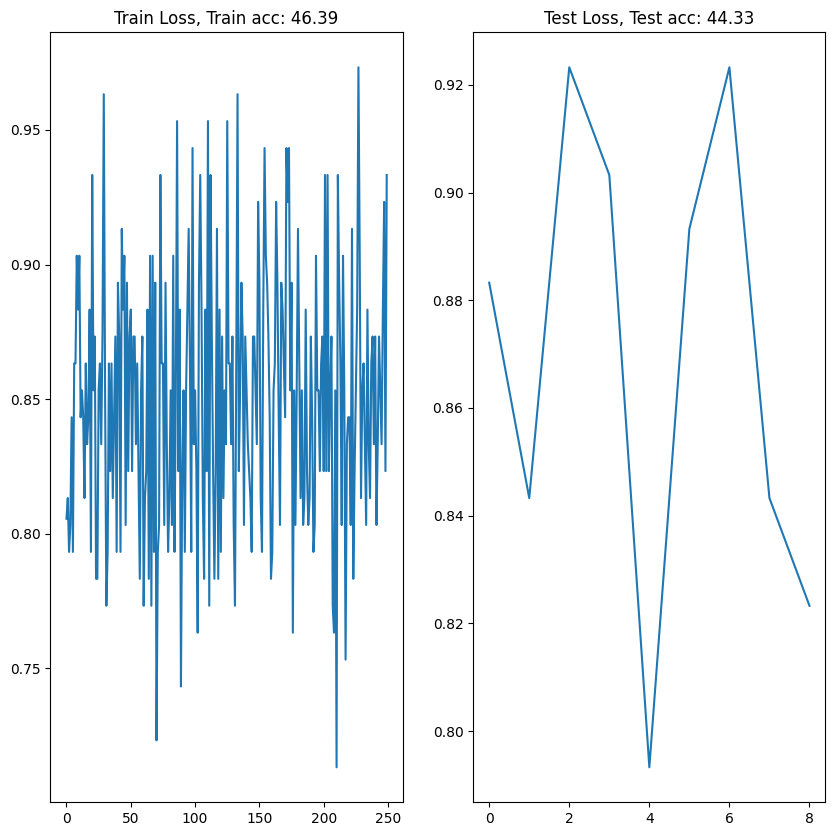

Result with STD : 1
------------------------------------------------------------------------------------------------------------------------------------------------------


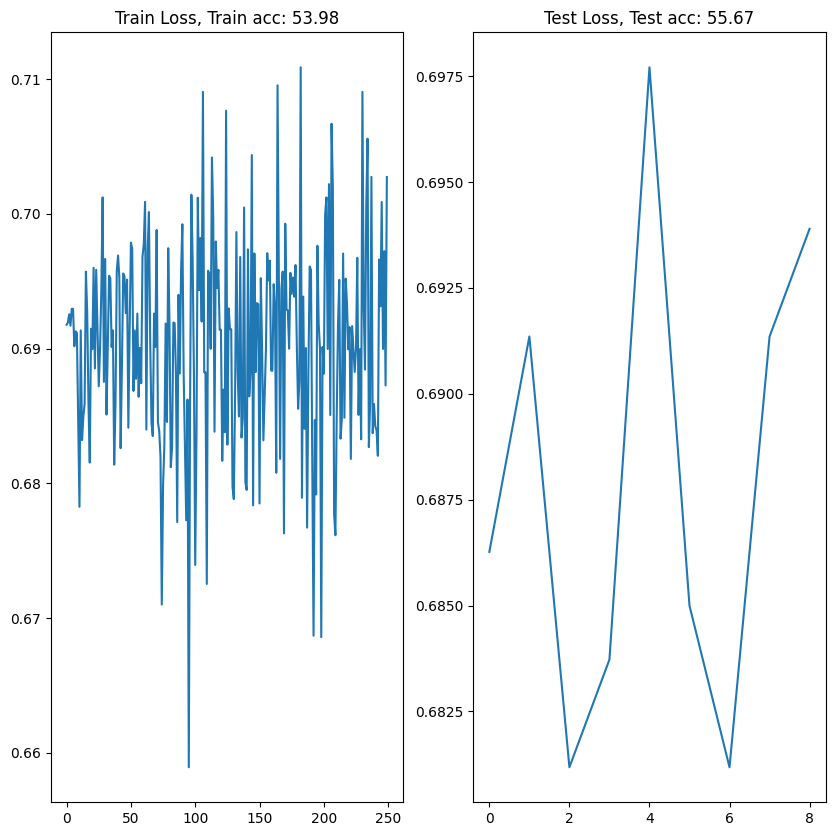

Result with STD : 0.1
------------------------------------------------------------------------------------------------------------------------------------------------------


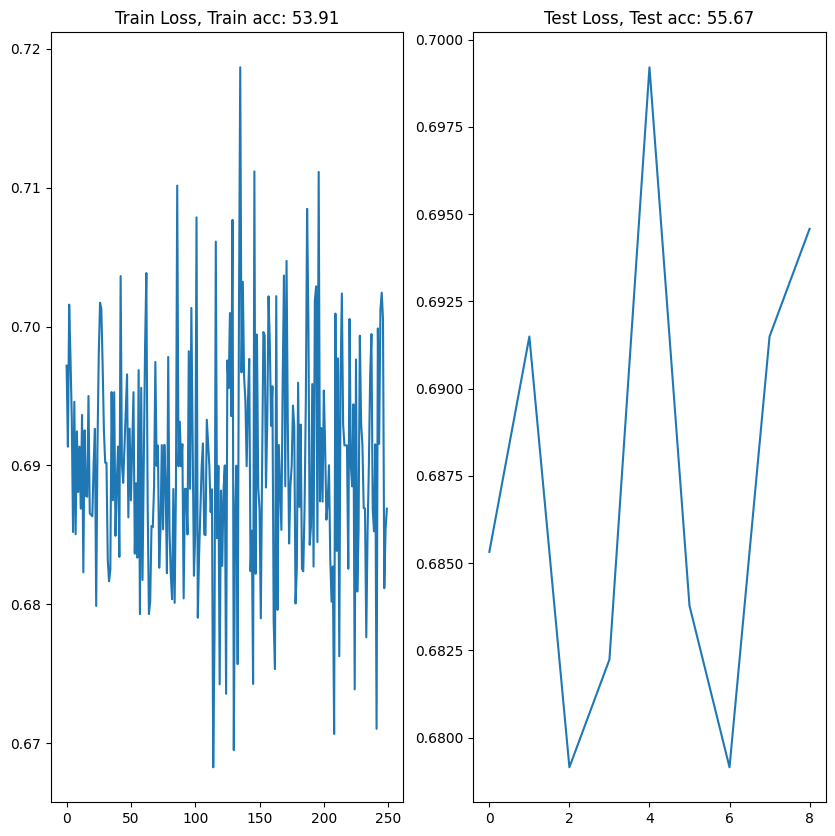

Result with STD : 0.01
------------------------------------------------------------------------------------------------------------------------------------------------------


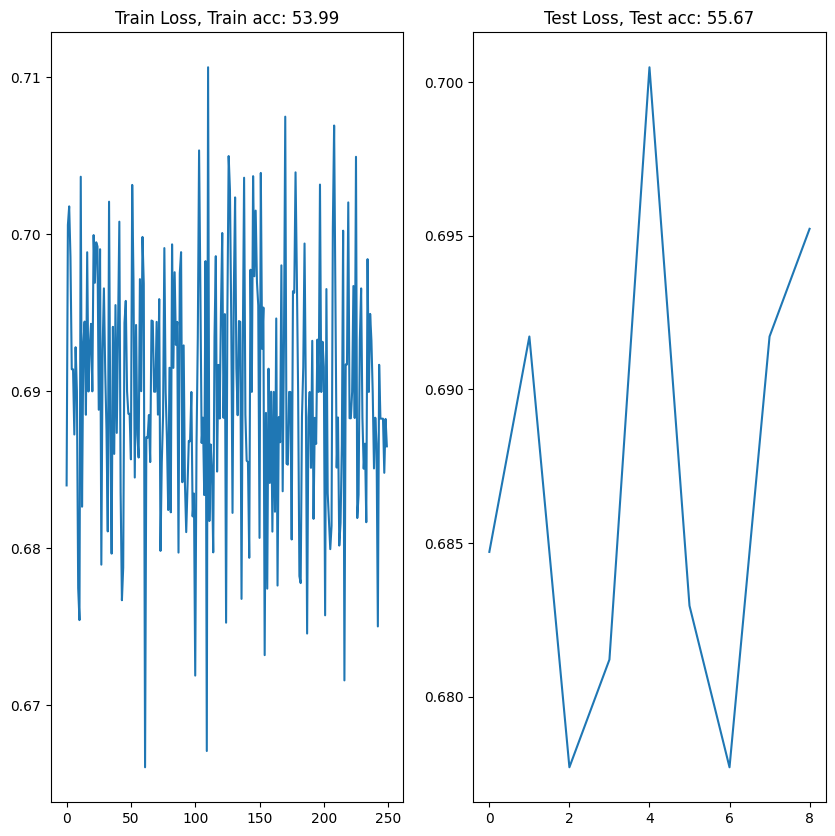

Result with STD : 0.001


In [48]:
stds = [
    "BASIC",
    10,
    1,
    1e-1,
    1e-2,
    1e-3,
]
models = [
    shallow_model,
    deep_model
]

@tr.no_grad()
def init_weights(m, mean, std):
    def sub_init(sub_m):
        if type(sub_m) == nn.Linear:
            sub_m.weight.normal_(mean=mean, std=std)
    m.apply(sub_init)
    
    # for p in m.parameters():
    #     tr.nn.init.normal_(p, mean=mean, std=std)

for mod in models:
    print("#"*150)
    print(f"Result with MODEL : {mod}")
    
    for ix, std in enumerate(stds):
        print("-"*150)
        if ix!=0:
            init_weights(mod, mean=0, std=std)
        tr_l, tr_acc = train(mod, train_input, train_target)
        te_l, te_acc = calc_nb_errors(mod, test_input, test_target)

        show_res(tr_l, te_l,tr_acc, te_acc)
        print(f"Result with STD : {std}") 


Эффект заметен не особо сильно...